<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.model_download('felicitaarcadia/predicting-student-bullying-experiences/scikitLearn/default/3')



  0%|          | 0.00/59.1k [00:00<?, ?B/s]
  0%|          | 0.00/1.23M [00:00<?, ?B/s]




100%|██████████| 59.1k/59.1k [00:00<00:00, 983kB/s]




100%|██████████| 5.40k/5.40k [00:00<00:00, 2.37MB/s]



  0%|          | 0.00/6.33M [00:00<?, ?B/s]



  0%|          | 0.00/1.53M [00:00<?, ?B/s]
 81%|████████▏ | 1.00M/1.23M [00:01<00:00, 877kB/s]


100%|██████████| 1.23M/1.23M [00:01<00:00, 1.03MB/s]



100%|██████████| 2.08M/2.08M [00:01<00:00, 1.54MB/s]




 65%|██████▌   | 1.00M/1.53M [00:01<00:00, 917kB/s]

 16%|█▌        | 1.00M/6.33M [00:01<00:06, 880kB/s]



100%|██████████| 1.53M/1.53M [00:01<00:00, 1.27MB/s]


 32%|███▏      | 2.00M/6.33M [00:01<00:02, 1.72MB/s]

 47%|████▋     | 3.00M/6.33M [00:01<00:01, 2.71MB/s]

100%|██████████| 6.33M/6.33M [00:01<00:00, 3.81MB/s]


In [3]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Bullying_2018_Labels.csv')

# Read the CSV into a DataFrame
df = pd.read_csv(csv_file_path)

# Display the head of the DataFrame
df.head()

,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Body_condition,Cluster
0,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,0,1
1,No,No,No,13 years old,Male,0 times,1 time,Never,3 or more,0 days,Most of the time,Always,0,1
2,No,No,No,15 years old,Male,0 times,1 time,Never,3 or more,3 to 5 days,Most of the time,Always,0,1
3,No,No,Yes,13 years old,Male,0 times,2 or 3 times,Most of the time,3 or more,0 days,Rarely,Always,0,2
4,No,No,No,14 years old,Male,0 times,2 or 3 times,Most of the time,2,0 days,Always,Sometimes,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22766 entries, 0 to 22765
Data columns (total 14 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   Bullied_on_school_property_in_past_12_months      22766 non-null  object
 1   Bullied_not_on_school_property_in_past_12_months  22766 non-null  object
 2   Cyber_bullied_in_past_12_months                   22766 non-null  object
 3   Custom_Age                                        22766 non-null  object
 4   Sex                                               22766 non-null  object
 5   Physically_attacked                               22766 non-null  object
 6   Physical_fighting                                 22766 non-null  object
 7   Felt_lonely                                       22766 non-null  object
 8   Close_friends                                     22766 non-null  object
 9   Miss_school_no_permission   

In [5]:
df.isnull().sum()

,0
Bullied_on_school_property_in_past_12_months,0
Bullied_not_on_school_property_in_past_12_months,0
Cyber_bullied_in_past_12_months,0
Custom_Age,0
Sex,0
Physically_attacked,0
Physical_fighting,0
Felt_lonely,0
Close_friends,0
Miss_school_no_permission,0


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, r2_score

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Cluster', errors='ignore')

# Handle the 'Cluster' column: remove it from features if it exists
# We will not use the 'Cluster' column as input for unsupervised clustering
features_df = df.drop(columns=['Cluster'], errors='ignore')

# One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(features_df[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Combine encoded categorical features with numerical features
# Ensure that numerical_cols only contains columns present in features_df
final_numerical_cols = [col for col in numerical_cols if col in features_df.columns]
if final_numerical_cols:
    processed_df = pd.concat([encoded_df, features_df[final_numerical_cols].reset_index(drop=True)], axis=1)
else:
    processed_df = encoded_df

# Initialize and train KMeans with default settings (e.g., n_clusters=8 by default in scikit-learn >= 0.23)
# It's good practice to specify n_init to suppress warnings if not explicitly provided.
kmeans = KMeans(random_state=42, n_init=10) # Using default n_clusters
kmeans.fit(processed_df)

# Add the cluster labels to the original DataFrame
df['KMeans_Cluster'] = kmeans.labels_

print("K-Means clustering completed. New column 'KMeans_Cluster' added to the DataFrame.")
print(df[['KMeans_Cluster']].head())


# --- Supervised Learning (Train-Test Split, Accuracy, R2 Score) ---

# Prepare data for supervised learning
# X will be the processed features (excluding the original 'Cluster' column)
X = processed_df
# y will be the original 'Cluster' column
y = df['Cluster']

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify for balanced classes

# Initialize and train a classification model (Logistic Regression)
# Using a simple classifier because the target 'Cluster' seems to be discrete labels.
classifier = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear') # Increased max_iter and specified solver for convergence
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Calculate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score for predicting original 'Cluster' using Logistic Regression: {accuracy:.4f}")

# R2 Score is typically for regression tasks.
# Since 'Cluster' is treated as a classification target (discrete labels),
# R2 score is not directly applicable or meaningful for evaluating this classification model.
# If 'Cluster' were a continuous numerical target, R2 would measure the proportion of variance explained.
print("\nR2 Score is primarily used for regression models to evaluate the proportion of variance in the dependent variable that is predictable from the independent variables.")
print("For this classification task (predicting 'Cluster'), R2 score is not an appropriate metric.")

K-Means clustering completed. New column 'KMeans_Cluster' added to the DataFrame.
   KMeans_Cluster
0               7
1               0
2               0
3               0
4               3

Accuracy Score for predicting original 'Cluster' using Logistic Regression: 0.9993

R2 Score is primarily used for regression models to evaluate the proportion of variance in the dependent variable that is predictable from the independent variables.
For this classification task (predicting 'Cluster'), R2 score is not an appropriate metric.


The **Elbow Method** is a heuristic used to determine the optimal number of clusters (k) for K-Means clustering.

### Geometric Intuition:

1.  **What does the Elbow Graph Plot?**
    *   The x-axis typically represents the number of clusters (k).
    *   The y-axis represents the **Within-Cluster Sum of Squares (WCSS)**, also known as **inertia**. WCSS measures the sum of the squared distances between each point and the centroid of its assigned cluster. Lower WCSS generally means denser and better-separated clusters.

2.  **How it Works (Geometric Interpretation):**
    *   **Decreasing WCSS with increasing k:** As you increase the number of clusters (k), the WCSS will naturally decrease. This is because when you add more clusters, each cluster will become smaller, and the data points within each cluster will be closer to their respective centroids. Imagine dividing a large group of scattered points into smaller, tighter groups; the overall spread within those groups will reduce.

    *   **The 'Elbow' Point:** The key is to find the point where the decrease in WCSS begins to slow down significantly. If you plot WCSS against k, you'll often see a graph that looks like an arm. The "elbow" of this arm is the point of diminishing returns. Before the elbow, adding another cluster provides a substantial reduction in WCSS, indicating that you're capturing more distinct structures in the data.

    *   **Beyond the Elbow:** After the elbow point, adding more clusters provides only a marginal decrease in WCSS. Geometrically, this means that you are mostly just splitting existing, already relatively compact clusters into even smaller, slightly more compact clusters, rather than identifying new, fundamentally different groupings. The benefits of adding more clusters (in terms of reducing within-cluster variance) no longer outweigh the increased complexity.

3.  **Why 'Elbow'?**
    *   The curve looks like an arm, and the "elbow" is the point where the bend is most pronounced. This bend signifies the optimal balance: enough clusters to capture the data's structure, but not so many that you're overfitting or just subdividing naturally cohesive groups. It's the point where adding more clusters doesn't significantly improve the compactness of the clusters anymore.

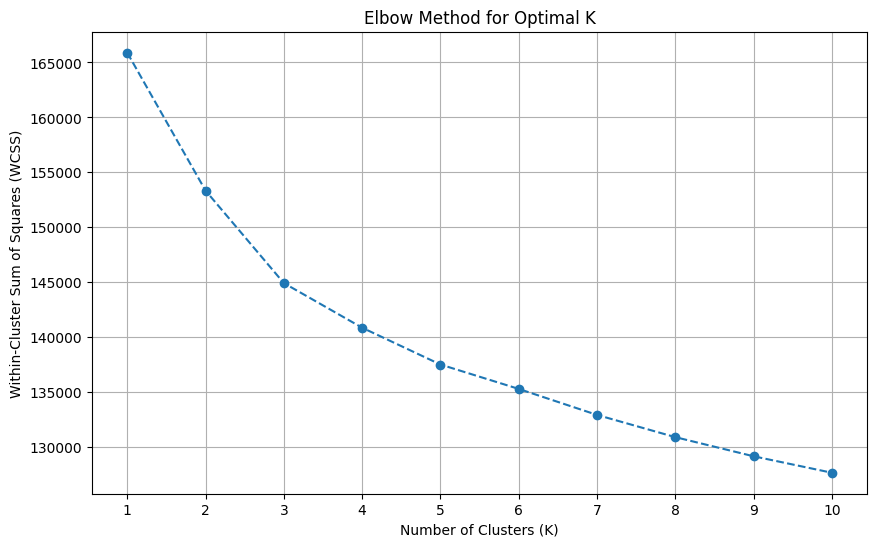

In [11]:
wcss = []
# Determine a reasonable range for K, e.g., from 1 to 10
# You might adjust this range based on your dataset size and expected number of clusters
max_k = 10

for i in range(1, max_k + 1):
    kmeans_model = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_model.fit(processed_df) # Use processed_df from previous steps
    wcss.append(kmeans_model.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

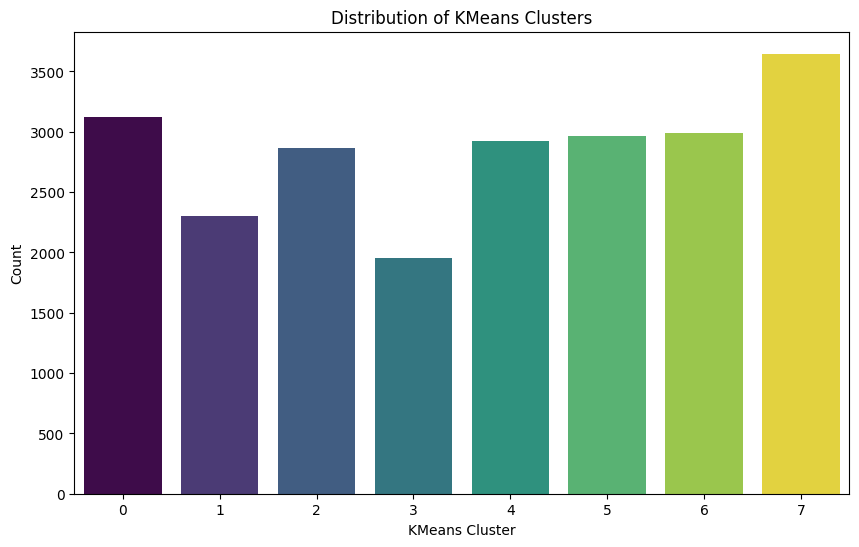

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of 'KMeans_Cluster'
plt.figure(figsize=(10, 6))
sns.countplot(x='KMeans_Cluster', data=df, palette='viridis', hue='KMeans_Cluster', legend=False)
plt.title('Distribution of KMeans Clusters')
plt.xlabel('KMeans Cluster')
plt.ylabel('Count')
plt.show()